# Mask Models

Once we have the data, we can build some models to test them and see how they perform versus one another. Something we care about is the performance of the model (accuracy) of predicting whether or not something is a bulk layer or not.


In [1]:
%pip install PyWavelets
%pip install tqdm
%pip install autogluon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opentelemetry-sdk to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 19.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is still looking at multiple versions of openxlab to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longe

In [2]:
import os

import numpy as np
import pandas as pd
from tqdm import tqdm
import pywt
import autogluon.core as ag
from autogluon.tabular import TabularDataset, TabularPredictor

In [6]:
import pandas as pd
from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.model_selection import train_test_split

feature_function_name = "wavelet_features"
resolution = 4

df = pd.read_csv(f"./{feature_function_name}_resolution_{resolution}.csv")
df['target'] = (df['id2_binary'] != 0).astype(int)
df = df.drop(columns=['bulk', 'id2', 'id2_binary'])  # keep 'file' this time

print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['target'].value_counts()}")

# ── Split by file, not by row ──────────────────────────────────────────────
files = df['file'].unique()
file_labels = df.groupby('file')['target'].max()  # one label per file for stratification

train_files, test_files = train_test_split(
    files,
    test_size=0.3,
    random_state=42,
    stratify=file_labels[files]  # stratify by file-level label
)

train_df = df[df['file'].isin(train_files)]
test_df  = df[df['file'].isin(test_files)]

print(f"Train files: {len(train_files)}, Test files: {len(test_files)}")
print(f"Train rows: {train_df.shape}, Test rows: {test_df.shape}")

# ── Drop file before passing to AutoGluon ─────────────────────────────────
# Keep a copy of test_df WITH file for layer-level aggregation later
test_df_with_file = test_df.copy()

train_data = TabularDataset(train_df.drop(columns=['file']))
test_data  = TabularDataset(test_df.drop(columns=['file']))

# ── Train ──────────────────────────────────────────────────────────────────
predictor = TabularPredictor(
    label='target',
    problem_type='binary',
    eval_metric='f1',
    path='./autogluon_models'
).fit(
    train_data,
    time_limit=600,
    presets='best_quality',
    verbosity=2
)

# ── Evaluate ───────────────────────────────────────────────────────────────
leaderboard  = predictor.leaderboard(test_data, silent=False)
performance  = predictor.evaluate(test_data)
importance   = predictor.feature_importance(test_data)

print("\nPerformance metrics:", performance)
print("\nFeature importance:\n", importance)

results = {
    'performance': performance,
    'best_model_score': leaderboard.iloc[0]['score_test'],
    'leaderboard': leaderboard
}

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       9.63 GB / 12.67 GB (76.0%)
Disk Space Avail:   74.34 GB / 107.72 GB (69.0%)
Presets specified: ['best_quality']


Dataset shape: (60914, 11)
Target distribution:
target
0    56457
1     4457
Name: count, dtype: int64
Train files: 265, Test files: 114
Train rows: (42691, 11), Test rows: (18223, 11)


Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will be fit on subsets of the data. Then holdout validation data is used to detect stacked overfitting.
	Running DyStack for up to 150s of the 600s of remaining time (25%).
		Context path: "/content/autogluon_models/ds_sub_fit/sub_fit_ho"
Leaderboard on holdout data (DyStack):
                 model  score_holdout  score_val eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal

                     model  score_test  score_val eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0          CatBoost_BAG_L1    0.447140   0.253666          f1        0.079580       0.126134   41.291319                 0.079580                0.126134          41.291319            1       True          5
1        LightGBMXT_BAG_L1    0.442123   0.276720          f1        3.252607       1.132037   54.455158                 3.252607                1.132037          54.455158            1       True          1
2        LightGBMXT_BAG_L2    0.437141   0.277426          f1        8.400289       6.068538  307.613362                 1.229880                0.668601          41.329369            2       True          7
3          LightGBM_BAG_L1    0.432778   0.282695          f1        2.018319       0.710695   45.279354                 2.018319                0.710695          45.27

Computing feature importance via permutation shuffling for 9 features using 5000 rows with 5 shuffle sets...
	31.03s	= Expected runtime (6.21s per shuffle set)
	29.85s	= Actual runtime (Completed 5 of 5 shuffle sets)



Performance metrics: {'f1': 0.4327784891165173, 'accuracy': 0.9270701860286451, 'balanced_accuracy': np.float64(0.6747150667068577), 'mcc': np.float64(0.39926805173742685), 'roc_auc': np.float64(0.7856400215473265), 'precision': 0.5044776119402985, 'recall': 0.3789237668161435}

Feature importance:
                               importance    stddev   p_value  n  p99_high  \
wavelet_level_4_energy_ratio    0.213124  0.038256  0.000119  5  0.291894   
wavelet_level_3_energy_ratio    0.060211  0.018960  0.001039  5  0.099250   
wavelet_level_5_energy_ratio    0.047310  0.014866  0.001030  5  0.077919   
wavelet_level_2_energy_ratio    0.030772  0.003270  0.000015  5  0.037504   
wavelet_level_0_energy_ratio    0.028324  0.009982  0.001581  5  0.048878   
wavelet_level_1_energy_ratio    0.006012  0.006468  0.053111  5  0.019329   
subsegment_index               -0.000785  0.009188  0.571119  5  0.018133   
mean_laser_current             -0.001844  0.007851  0.686371  5  0.014321   
scan_

In [7]:
results

{'performance': {'f1': 0.4327784891165173,
  'accuracy': 0.9270701860286451,
  'balanced_accuracy': np.float64(0.6747150667068577),
  'mcc': np.float64(0.39926805173742685),
  'roc_auc': np.float64(0.7856400215473265),
  'precision': 0.5044776119402985,
  'recall': 0.3789237668161435},
 'best_model_score': np.float64(0.44714038128249567),
 'leaderboard':                      model  score_test  score_val eval_metric  pred_time_test  \
 0          CatBoost_BAG_L1    0.447140   0.253666          f1        0.079580   
 1        LightGBMXT_BAG_L1    0.442123   0.276720          f1        3.252607   
 2        LightGBMXT_BAG_L2    0.437141   0.277426          f1        8.400289   
 3          LightGBM_BAG_L1    0.432778   0.282695          f1        2.018319   
 4      WeightedEnsemble_L2    0.432778   0.282695          f1        2.020881   
 5      WeightedEnsemble_L3    0.432778   0.282695          f1        2.021276   
 6          LightGBM_BAG_L2    0.432027   0.282540          f1        

Layer-level dataset: (114, 3)
Layer target distribution:
true_label
0    106
1      8
Name: count, dtype: int64

Optimal threshold: 0.905
Best F1 at threshold: 0.8571

Layer-level performance at threshold=0.905:
  F1:        0.8571
  Precision: 1.0000
  Recall:    0.7500
  Accuracy:  0.9825


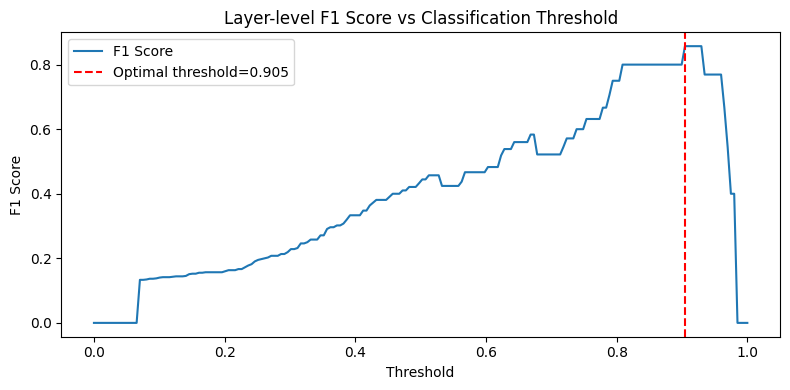

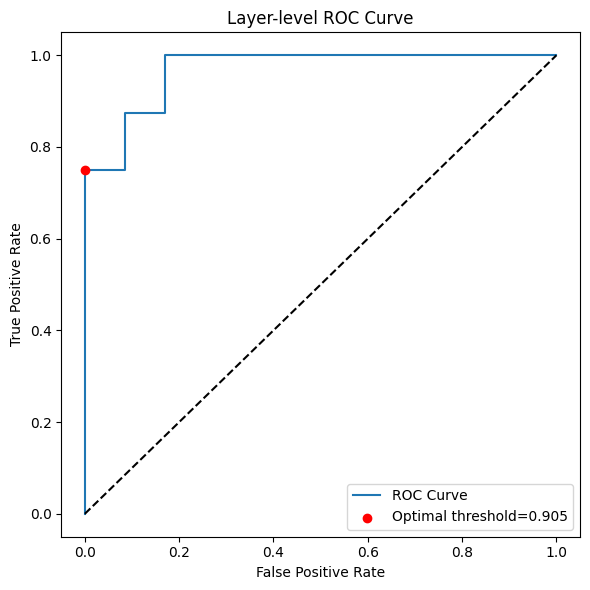

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve
import matplotlib.pyplot as plt

# ── 1. Get subsegment-level probabilities ──────────────────────────────────
# predict_proba returns probability for each class [p(0), p(1)]
proba = predictor.predict_proba(test_data)
test_df_with_file['proba_error'] = proba[1].reset_index(drop=True).values
# ── 2. Aggregate to file (layer) level via max probability ─────────────────
layer_df = (
    test_df_with_file.groupby('file')
    .agg(
        layer_score=('proba_error', 'max'),   # max probability across all subsegments
        true_label=('target', 'max')          # if any subsegment is error, layer is error
    )
    .reset_index()
)

print(f"Layer-level dataset: {layer_df.shape}")
print(f"Layer target distribution:\n{layer_df['true_label'].value_counts()}")

# ── 3. Find optimal cutoff that maximizes F1 ──────────────────────────────
thresholds = np.linspace(0, 1, 200)
f1_scores  = []

for thresh in thresholds:
    preds = (layer_df['layer_score'] >= thresh).astype(int)
    # avoid edge case where all predictions are one class
    if preds.nunique() < 2:
        f1_scores.append(0)
    else:
        f1_scores.append(f1_score(layer_df['true_label'], preds))

best_idx    = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1     = f1_scores[best_idx]

print(f"\nOptimal threshold: {best_thresh:.3f}")
print(f"Best F1 at threshold: {best_f1:.4f}")

# ── 4. Evaluate at optimal threshold ──────────────────────────────────────
final_preds = (layer_df['layer_score'] >= best_thresh).astype(int)

print(f"\nLayer-level performance at threshold={best_thresh:.3f}:")
print(f"  F1:        {f1_score(layer_df['true_label'], final_preds):.4f}")
print(f"  Precision: {precision_score(layer_df['true_label'], final_preds):.4f}")
print(f"  Recall:    {recall_score(layer_df['true_label'], final_preds):.4f}")
print(f"  Accuracy:  {(final_preds == layer_df['true_label']).mean():.4f}")

# ── 5. Plot F1 vs threshold ────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.axvline(best_thresh, color='red', linestyle='--', label=f'Optimal threshold={best_thresh:.3f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Layer-level F1 Score vs Classification Threshold')
plt.legend()
plt.tight_layout()
plt.show()

# ── 6. Plot ROC curve ──────────────────────────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(layer_df['true_label'], layer_df['layer_score'])
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label='ROC Curve')
plt.scatter(
    fpr[np.argmin(np.abs(roc_thresholds - best_thresh))],
    tpr[np.argmin(np.abs(roc_thresholds - best_thresh))],
    color='red', zorder=5, label=f'Optimal threshold={best_thresh:.3f}'
)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Layer-level ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()


  Mask: first 20% of each layer


/tmp/ipykernel_411/3787962244.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(keep_first_fraction)


  Optimal threshold: 0.503
  F1:        0.8235
  Precision: 0.7778
  Recall:    0.8750
  Accuracy:  0.9737

  Mask: first 25% of each layer


/tmp/ipykernel_411/3787962244.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(keep_first_fraction)


  Optimal threshold: 0.623
  F1:        0.7778
  Precision: 0.7000
  Recall:    0.8750
  Accuracy:  0.9649

  Mask: first 30% of each layer


...

  Optimal threshold: 0.905
  F1:        0.8571
  Precision: 1.0000
  Recall:    0.7500
  Accuracy:  0.9825

  Mask: first 80% of each layer


/tmp/ipykernel_411/3787962244.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(keep_first_fraction)


  Optimal threshold: 0.905
  F1:        0.8571
  Precision: 1.0000
  Recall:    0.7500
  Accuracy:  0.9825

  Mask: first 100% of each layer


/tmp/ipykernel_411/3787962244.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(keep_first_fraction)


  Optimal threshold: 0.905
  F1:        0.8571
  Precision: 1.0000
  Recall:    0.7500
  Accuracy:  0.9825

 fraction  threshold       f1  precision  recall  accuracy
     20%   0.502513 0.823529   0.777778   0.875  0.973684
     25%   0.623116 0.777778   0.700000   0.875  0.964912
     30%   0.904523 0.769231   1.000000   0.625  0.973684
     35%   0.809045 0.800000   0.857143   0.750  0.973684
     40%   0.809045 0.800000   0.857143   0.750  0.973684
     45%   0.809045 0.800000   0.857143   0.750  0.973684
     50%   0.809045 0.800000   0.857143   0.750  0.973684
     55%   0.809045 0.800000   0.857143   0.750  0.973684
     60%   0.904523 0.857143   1.000000   0.750  0.982456
     65%   0.904523 0.857143   1.000000   0.750  0.982456
     70%   0.904523 0.857143   1.000000   0.750  0.982456
     75%   0.904523 0.857143   1.000000   0.750  0.982456
     80%   0.904523 0.857143   1.000000   0.750  0.982456
    100%   0.904523 0.857143   1.000000   0.750  0.982456


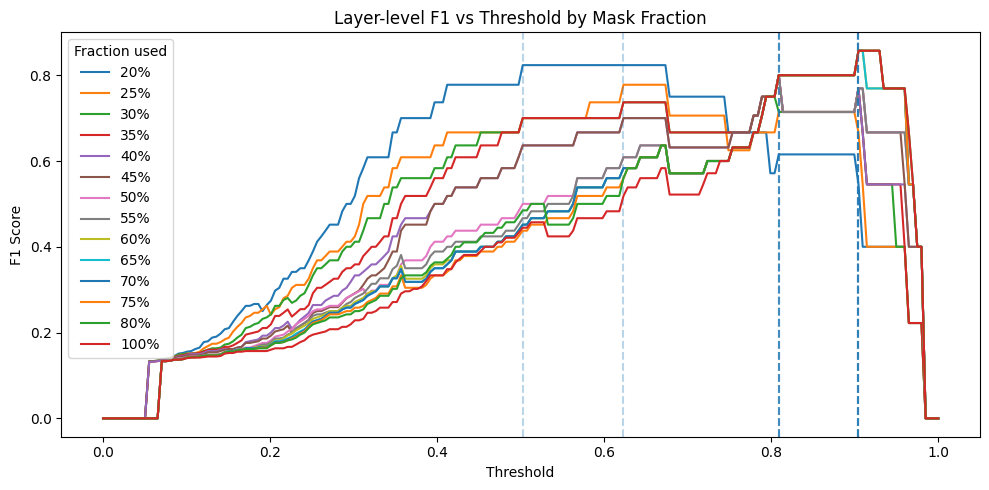

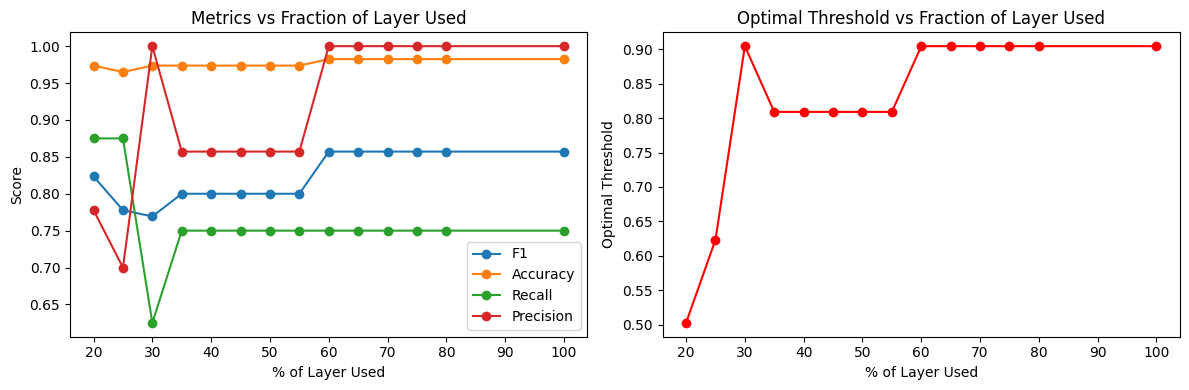

In [10]:
## We masking now
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, roc_curve
import matplotlib.pyplot as plt

fractions = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 1.0]  # 1.0 = full layer (baseline)
fraction_results = {}

for fraction in fractions:
    print(f"\n{'='*60}")
    print(f"  Mask: first {int(fraction*100)}% of each layer")
    print(f"{'='*60}")

    # ── 1. Mask test_df_with_file to first X% of subsegments per file ──────
    def keep_first_fraction(group):
        n_keep = max(1, int(np.ceil(len(group) * fraction)))
        return group.iloc[:n_keep]

    masked_df = (
        test_df_with_file
        .groupby('file', group_keys=False)
        .apply(keep_first_fraction)
        .reset_index(drop=True)
    )

    # ── 2. Aggregate to layer level ────────────────────────────────────────
    layer_df = (
        masked_df.groupby('file')
        .agg(
            layer_score=('proba_error', 'max'),
            true_label=('target', 'max')
        )
        .reset_index()
    )

    # ── 3. Find optimal threshold ──────────────────────────────────────────
    thresholds = np.linspace(0, 1, 200)
    f1_scores  = []

    for thresh in thresholds:
        preds = (layer_df['layer_score'] >= thresh).astype(int)
        if preds.nunique() < 2:
            f1_scores.append(0)
        else:
            f1_scores.append(f1_score(layer_df['true_label'], preds))

    best_idx    = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]

    # ── 4. Evaluate at optimal threshold ──────────────────────────────────
    final_preds = (layer_df['layer_score'] >= best_thresh).astype(int)

    metrics = {
        'fraction':   fraction,
        'threshold':  best_thresh,
        'f1':         f1_score(layer_df['true_label'], final_preds),
        'precision':  precision_score(layer_df['true_label'], final_preds),
        'recall':     recall_score(layer_df['true_label'], final_preds),
        'accuracy':   (final_preds == layer_df['true_label']).mean(),
    }
    fraction_results[fraction] = {
        **metrics,
        'layer_df':   layer_df,
        'f1_curve':   (thresholds, f1_scores),
    }

    print(f"  Optimal threshold: {best_thresh:.3f}")
    print(f"  F1:        {metrics['f1']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")

# ── 5. Summary table ───────────────────────────────────────────────────────
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['layer_df', 'f1_curve']}
    for r in fraction_results.values()
])
summary['fraction'] = summary['fraction'].apply(lambda x: f"{int(x*100)}%")
print("\n", summary.to_string(index=False))

# ── 6. Plot F1 vs threshold for all fractions ──────────────────────────────
plt.figure(figsize=(10, 5))
for fraction, r in fraction_results.items():
    thresholds, f1_scores = r['f1_curve']
    plt.plot(thresholds, f1_scores, label=f"{int(fraction*100)}%")
    plt.axvline(r['threshold'], linestyle='--', alpha=0.3)
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Layer-level F1 vs Threshold by Mask Fraction')
plt.legend(title='Fraction used')
plt.tight_layout()
plt.show()

# ── 7. Plot metrics vs fraction ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fracs = [int(f*100) for f in fractions]
axes[0].plot(fracs, [fraction_results[f]['f1'] for f in fractions], marker='o', label='F1')
axes[0].plot(fracs, [fraction_results[f]['accuracy'] for f in fractions], marker='o', label='Accuracy')
axes[0].plot(fracs, [fraction_results[f]['recall'] for f in fractions], marker='o', label='Recall')
axes[0].plot(fracs, [fraction_results[f]['precision'] for f in fractions], marker='o', label='Precision')
axes[0].set_xlabel('% of Layer Used')
axes[0].set_ylabel('Score')
axes[0].set_title('Metrics vs Fraction of Layer Used')
axes[0].legend()

axes[1].plot(fracs, [fraction_results[f]['threshold'] for f in fractions], marker='o', color='red')
axes[1].set_xlabel('% of Layer Used')
axes[1].set_ylabel('Optimal Threshold')
axes[1].set_title('Optimal Threshold vs Fraction of Layer Used')

plt.tight_layout()
plt.show()

## Below is dead code

In [3]:
import pandas as pd
from autogluon.tabular import TabularDataset, TabularPredictor
from sklearn.model_selection import train_test_split

# ── 1. Load your preprocessed CSV ──────────────────────────────────────────
feature_function_name = "wavelet_features"  # or "simple_statistics"
resolution = 4                             # whichever resolution you used

df = pd.read_csv(f"./{feature_function_name}_resolution_{resolution}.csv")

# ── 2. Ensure target is binary ─────────────────────────────────────────────
# Inspect unique values first
print("Unique 'bulk' values:", df['bulk'].unique())

# If bulk is numeric, binarize it (adjust threshold as needed)
# e.g. if 0 = no error, anything else = error
df['target'] = (df['id2_binary'] != 0).astype(int)

# ── 3. Drop columns that would leak identity info ──────────────────────────
# 'file' and 'bulk' are not features — drop them
# Keep: scan_number, subsegment_index, mean_laser_current, all wavelet/stat cols
drop_cols = ['file', 'bulk', 'id2', 'id2_binary']
df = df.drop(columns=drop_cols)

print(f"Dataset shape: {df.shape}")
print(f"Target distribution:\n{df['target'].value_counts()}")

# ── 4. Train/test split — split by file to avoid data leakage ──────────────
# (if you kept 'file' col, group-split here instead)
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['target'])

print(f"Train: {train_df.shape}, Test: {test_df.shape}")

# ── 5. Convert to AutoGluon Dataset ───────────────────────────────────────
train_data = TabularDataset(train_df)
test_data  = TabularDataset(test_df)

# ── 6. Train ───────────────────────────────────────────────────────────────
predictor = TabularPredictor(
    label='target',
    problem_type='binary',
    eval_metric='f1',      # good default for imbalanced binary classification
    path='./autogluon_models'   # saves models here for reuse
).fit(
    train_data,
    time_limit=600,             # seconds — increase for better results
    presets='best_quality',     # or 'medium_quality' for faster runs
    verbosity=2
)

# ── 7. Evaluate ────────────────────────────────────────────────────────────
leaderboard = predictor.leaderboard(test_data, silent=False)
print(leaderboard)

# ── 8. Detailed performance metrics ───────────────────────────────────────
performance = predictor.evaluate(test_data)
print("\nPerformance metrics:", performance)

# ── 9. Feature importance ──────────────────────────────────────────────────
importance = predictor.feature_importance(test_data)
print("\nFeature importance:\n", importance)

results = {
        'performance': performance,
        #'best_model_name': predictor['model'],
        'best_model_score': leaderboard.iloc[0]['score_test'],
        'leaderboard': leaderboard
    }

Verbosity: 2 (Standard Logging)


Unique 'bulk' values: [1. 0.]
Dataset shape: (60914, 10)
Target distribution:
target
0    56457
1     4457
Name: count, dtype: int64
Train: (42639, 10), Test: (18275, 10)


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
Memory Avail:       11.10 GB / 12.67 GB (87.6%)
Disk Space Avail:   74.74 GB / 107.72 GB (69.4%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by stacked overfitting and enable or disable stacking as a consequence.
	This is used to identify the optimal `num_stack_levels` value. Copies of AutoGluon will 

                     model  score_test  score_val eval_metric  pred_time_test  pred_time_val    fit_time  pred_time_test_marginal  pred_time_val_marginal  fit_time_marginal  stack_level  can_infer  fit_order
0          CatBoost_BAG_L1    0.395475   0.305968          f1        0.285771       0.083037   60.424855                 0.285771                0.083037          60.424855            1       True          5
1          LightGBM_BAG_L1    0.392463   0.317786          f1        1.804852       0.902355   41.230673                 1.804852                0.902355          41.230673            1       True          2
2      WeightedEnsemble_L2    0.392463   0.317786          f1        1.808793       0.913779   42.311593                 0.003941                0.011424           1.080920            2       True          6
3        LightGBMXT_BAG_L2    0.391904   0.322318          f1        8.240043       6.756745  306.698217                 1.163380                0.663759          40.31

Computing feature importance via permutation shuffling for 9 features using 5000 rows with 5 shuffle sets...



Performance metrics: {'f1': 0.39190432382704693, 'accuracy': 0.9276607387140903, 'balanced_accuracy': np.float64(0.647179409122257), 'mcc': np.float64(0.36665934049218973), 'roc_auc': np.float64(0.7867328935049585), 'precision': 0.5089605734767025, 'recall': 0.318623784592371}


	117.86s	= Expected runtime (23.57s per shuffle set)
	116.38s	= Actual runtime (Completed 5 of 5 shuffle sets)



Feature importance:
                               importance    stddev       p_value  n  p99_high  \
wavelet_level_4_energy_ratio    0.215064  0.008766  3.305069e-07  5  0.233114   
wavelet_level_3_energy_ratio    0.078239  0.021308  5.995924e-04  5  0.122112   
wavelet_level_5_energy_ratio    0.048849  0.008209  9.218719e-05  5  0.065751   
wavelet_level_2_energy_ratio    0.033277  0.012112  1.779962e-03  5  0.058216   
wavelet_level_0_energy_ratio    0.022231  0.018258  2.642098e-02  5  0.059825   
wavelet_level_1_energy_ratio    0.020456  0.011145  7.400688e-03  5  0.043402   
scan_number                     0.010451  0.005575  6.894099e-03  5  0.021931   
mean_laser_current              0.004588  0.006468  9.394255e-02  5  0.017906   
subsegment_index               -0.001757  0.009588  6.484877e-01  5  0.017985   

                               p99_low  
wavelet_level_4_energy_ratio  0.197015  
wavelet_level_3_energy_ratio  0.034367  
wavelet_level_5_energy_ratio  0.031947  
wav

In [ ]:
from sklearn.model_selection import train_test_split

# ── 1. Load your preprocessed CSV ──────────────────────────────────────────
feature_function_name = "wavelet_features"
resolution = 4

df = pd.read_csv(f"./{feature_function_name}_resolution_{resolution}.csv")
df['target'] = (df['id2_binary'] != 0).astype(int)
df = df.drop(columns=['bulk', 'id2', 'id2_binary'])

# ── 2. Define masking function ─────────────────────────────────────────────
def mask_layer(df, fraction):
    """
    Keep only the first `fraction` of subsegments per (file, scan_number).
    e.g. fraction=0.2 keeps the first 20% of subsegments in each scan.
    """
    def keep_first_fraction(group):
        n_keep = max(1, int(np.ceil(len(group) * fraction)))
        return group.iloc[:n_keep]

    return (
        df.groupby(['file', 'scan_number'], group_keys=False)
          .apply(keep_first_fraction)
          .reset_index(drop=True)
    )

# ── 3. Run AutoGluon for each mask fraction ────────────────────────────────
fractions = [0.2, 0.3, 0.5, 0.7, 1]
results = {}  # stores performance metrics per fraction

for fraction in fractions:
    print(f"\n{'='*60}")
    print(f"  Training on first {int(fraction*100)}% of each layer")
    print(f"{'='*60}")

    # Apply mask
    masked_df = mask_layer(df, fraction)
    masked_df = masked_df.drop(columns=['file'])  # drop after masking

    print(f"  Masked dataset shape: {masked_df.shape}")
    print(f"  Target distribution:\n{masked_df['target'].value_counts()}")

    # Train/test split
    train_df, test_df = train_test_split(
        masked_df,
        test_size=0.3,
        random_state=42,
        stratify=masked_df['target']
    )

    train_data = TabularDataset(train_df)
    test_data  = TabularDataset(test_df)

    # Train
    predictor = TabularPredictor(
        label='target',
        problem_type='binary',
        eval_metric='f1',
        path=f'./autogluon_models/fraction_{int(fraction*100)}pct'
    ).fit(
        train_data,
        time_limit=600,
        presets='best_quality',
        verbosity=1
    )

    # Evaluate
    performance = predictor.evaluate(test_data)
    leaderboard = predictor.leaderboard(test_data, silent=True)
    best_model  = leaderboard.iloc[0]  # top row = best model

    results[fraction] = {
        'performance': performance,
        'best_model_name': best_model['model'],
        'best_model_score': best_model['score_test'],
        'leaderboard': leaderboard
    }

    print(f"\n  ✅ Best model: {best_model['model']} | ROC-AUC: {best_model['score_test']:.4f}")

# ── 4. Summary table ───────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  SUMMARY")
print(f"{'='*60}")

summary = pd.DataFrame([
    {
        'fraction': f"{int(f*100)}%",
        'best_model': results[f]['best_model_name'],
        'roc_auc': results[f]['best_model_score'],
        **results[f]['performance']  # expands all metrics (accuracy, f1, etc.)
    }
    for f in fractions
])

print(summary.to_string(index=False))
summary.to_csv('./autogluon_models/summary.csv', index=False)
print("\nSummary saved to ./autogluon_models/summary.csv")


  Training on first 20% of each layer


/tmp/ipykernel_422/2467003792.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(keep_first_fraction)


  Masked dataset shape: (35443, 10)
  Target distribution:
target
0    33091
1     2352
Name: count, dtype: int64


2026-03-10 16:03:42,748	INFO worker.py:2014 -- Started a local Ray instance. View the dashboard at http://127.0.0.1:8265 
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2062: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(



  ✅ Best model: WeightedEnsemble_L3 | ROC-AUC: 0.3504

  Training on first 30% of each layer


...


  ✅ Best model: LightGBMXT_BAG_L2 | ROC-AUC: 0.3824

  Training on first 100% of each layer


/tmp/ipykernel_422/2467003792.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(keep_first_fraction)


  Masked dataset shape: (60914, 10)
  Target distribution:
target
0    56457
1     4457
Name: count, dtype: int64


	Not enough time to generate out-of-fold predictions for model. Estimated time required was 15.1s compared to 10s of available time.



  ✅ Best model: LightGBMXT_BAG_L1 | ROC-AUC: 0.3925

  SUMMARY
fraction             best_model  roc_auc       f1  accuracy  balanced_accuracy      mcc  precision   recall
     20%    WeightedEnsemble_L3 0.749764 0.350390  0.929559           0.630719 0.324359   0.451902 0.286119
     30%      LightGBMXT_BAG_L2 0.740815 0.322430  0.918646           0.627553 0.281393   0.360000 0.291961
     50% NeuralNetFastAI_BAG_L1 0.760111 0.353372  0.926598           0.630791 0.326609   0.459924 0.286905
     70%      LightGBMXT_BAG_L2 0.770808 0.382051  0.920611           0.650983 0.344396   0.444334 0.335082
    100%      LightGBMXT_BAG_L1 0.786228 0.389816  0.920000           0.657169 0.350332   0.440982 0.349289

Summary saved to ./autogluon_models/summary.csv


We're gonna be so honest here. Jonathan's scared of installing autogluon and destroying his computer and he did it last year, so he did this on Google Collab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
shutil.make_archive(
    base_name='/content/drive/MyDrive/autogluon_models',  # destination
    format='zip',
    root_dir='/content',
    base_dir='autogluon_models'                           # folder to zip
)

'/content/drive/MyDrive/autogluon_models.zip'